In [ ]:
from brian2 import *

import numpy as np
import os
from glob import glob
import cv2
import sys
sys.path.insert(0, r"C:\Users\reidj\Dropbox\dphil\programming\spikes\spikes")
from network import *
from input import *
from projects import *


# Section 1: Define Functions we'll need
## Section 1.1: Input preparation functions

In [ ]:
def load_gabor_filters(filter_dir):
    """
    Load all Gabor filter .npy files from a directory into a list of arrays.
    
    Args:
        filter_dir (str): Path to directory containing filter .npy files
        
    Returns:
        list: List of numpy arrays, each representing a Gabor filter
    """
    # Ensure path exists
    if not os.path.exists(filter_dir):
        raise FileNotFoundError(f"Filter directory not found: {filter_dir}")
    
    # Get all .npy files in the directory
    filter_files = glob(os.path.join(filter_dir, "*.npy"))
    
    if not filter_files:
        print(f"No .npy files found in {filter_dir}")
        return []
    
    # Load each filter into a list
    filters = []
    for file_path in filter_files:
        try:
            filter_array = np.load(file_path)
            filters.append(filter_array)
            print(f"Loaded filter from {os.path.basename(file_path)}, shape: {filter_array.shape}")
        except Exception as e:
            print(f"Error loading {file_path}: {str(e)}")
    
    print(f"Loaded {len(filters)} Gabor filters")
    return filters

def upscale_mnist(images, target_size=128, method='bicubic'):
    """
    Upscale MNIST images from 28x28 to target_size x target_size
    
    Args:
        images: NumPy array with shape (n_images, 28, 28)
        target_size: Target size (default: 128)
        method: Upscaling method ('nearest', 'bilinear', 'bicubic', or 'lanczos')
        
    Returns:
        NumPy array with shape (n_images, target_size, target_size)
    """
    num_images = images.shape[0]
    upscaled = np.zeros((num_images, target_size, target_size))
    
    for i in range(num_images):
        # OpenCV resize
        if method == 'nearest':
            interpolation = cv2.INTER_NEAREST
        elif method == 'bilinear':
            interpolation = cv2.INTER_LINEAR
        elif method == 'bicubic':
            interpolation = cv2.INTER_CUBIC
        elif method == 'lanczos':
            interpolation = cv2.INTER_LANCZOS4
        else:
            raise ValueError(f"Unknown method: {method}")
        
        # OpenCV takes (width, height) instead of (height, width)
        upscaled[i] = cv2.resize(images[i], (target_size, target_size), interpolation=interpolation)
        
    return upscaled


## 1.2: Visualisation of Input:


In [ ]:
def display_convolved_images(convolved_data, cmap='viridis', figsize=(15, 10)):
    """
    Display convolved images as heatmaps in a grid layout.
    
    Args:
        convolved_data: NumPy array with shape (n_images, n_filters, height, width)
        cmap: Colormap for the heatmap (default: 'viridis')
        figsize: Figure size (width, height) in inches
    """
    n_images, n_filters, height, width = convolved_data.shape
    
    # Create a figure with subplots - one row per image, one column per filter
    fig, axes = plt.subplots(n_images, n_filters, figsize=figsize)
    
    # Find global min and max for consistent color scaling across all heatmaps
    vmin = np.min(convolved_data)
    vmax = np.max(convolved_data)
    
    # Plotting each image × filter combination
    for img_idx in range(n_images):
        for filter_idx in range(n_filters):
            # Get current axis
            ax = axes[img_idx, filter_idx]
            
            # Display the heatmap
            im = ax.imshow(convolved_data[img_idx, filter_idx], 
                          cmap=cmap, 
                          vmin=vmin, vmax=vmax)
            
            # Remove axis ticks for cleaner display
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Add labels for first row and column only
            if img_idx == 0:
                ax.set_title(f"Filter {filter_idx}")
            if filter_idx == 0:
                ax.set_ylabel(f"Image {img_idx}")
    
    # Add a colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
    cbar.set_label('Activation Value')
    
    # Add overall title
    plt.suptitle("Convolved Images (MNIST) with Gabor Filters", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # Make room for suptitle
    
    return fig

def display_neuron_inputs(neuron_inputs, cmap='hot', figsize=(12, 8)):
    """
    Display neuron inputs as heatmaps.
    
    Args:
        neuron_inputs: NumPy array with shape (n_images, neuron_count) or (n_images, height, width)
        cmap: Colormap for the heatmap (default: 'hot')
        figsize: Figure size (width, height) in inches
    """
    # Check shape and reshape if needed
    if len(neuron_inputs.shape) == 2:
        # We need to estimate the grid size
        n_images, neuron_count = neuron_inputs.shape
        grid_size = int(np.sqrt(neuron_count))
        
        if grid_size**2 != neuron_count:
            print(f"Warning: Neuron count {neuron_count} is not a perfect square.")
            grid_size = int(np.sqrt(neuron_count))
            # Pad with zeros to make it square
            padded_count = grid_size**2
            padded_inputs = np.zeros((n_images, padded_count))
            padded_inputs[:, :neuron_count] = neuron_inputs
            neuron_inputs = padded_inputs.reshape(n_images, grid_size, grid_size)
        else:
            # Reshape to grid
            neuron_inputs = neuron_inputs.reshape(n_images, grid_size, grid_size)
    
    n_images = neuron_inputs.shape[0]
    
    # Calculate grid layout for subplots
    n_cols = min(5, n_images)
    n_rows = (n_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Find global min and max for consistent color scaling
    vmin = np.min(neuron_inputs)
    vmax = np.max(neuron_inputs)
    
    # Plot each image
    for i in range(n_images):
        ax = axes[i]
        im = ax.imshow(neuron_inputs[i], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"Image {i}")
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Hide unused subplots
    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Neuron Input Strength')
    
    plt.suptitle("Neuron Input Activations", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    
    return fig

# 2: Load in Data:
## 2.1: Load in MNIST

In [ ]:

import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
# 1) Load the train split as a tf.data.Dataset of (image, label) pairs
ds_train = tfds.load(
    "mnist",
    split="train",
    as_supervised=True,    # yields (image, label) tuples
    shuffle_files=False,   # no need to shuffle if you just want the first 10
)

# 2) Take only the first 10 examples
ds20 = ds_train.take(10)

# 3) Convert to NumPy and stack
#    - If you’re in Eager mode (TF2 default), .numpy() works on each tensor
mnist_images = np.stack([img.numpy() for img, lbl in ds20])
# mnist_images.shape == (120, 28, 28, 1)

# 4) (Optional) squeeze off the channel dimension if you want (10,28,28)
mnist_images = mnist_images.squeeze(-1)

# 5) Upscale:
upscaled_images = upscale_mnist(mnist_images, target_size=128, method='bicubic')
print(f"Original shape: {mnist_images.shape}, Upscaled shape: {upscaled_images.shape}")



## 2.2. Load in Gabor filters & convolve images, saving them to a file location:

In [ ]:
filter_dir = r"C:\Users\reidj\Dropbox\dphil\programming\spikes\projects\mnist_class\mnist_class_wip\configs\input\filters"
gabor_filters = load_gabor_filters(filter_dir)
convolved_images = convolve_images(upscaled_images, 
                    gabor_filters, 
                    r"C:\Users\reidj\Dropbox\dphil\programming\spikes\projects\mnist_class\mnist_class_wip\data\conv_mnist_20"
                    )


## 2.3: Now Generate Neuron Inputs by Combining the Inputs with the mapping:


In [ ]:
neuron_inputs = generate_neuron_inputs_from_saved(r"C:\Users\reidj\Dropbox\dphil\programming\spikes\projects\mnist_class\mnist_class_wip\data\conv_mnist_20.npy",
                                    r"C:\Users\reidj\Dropbox\dphil\programming\spikes\projects\mnist_class\mnist_class_wip\configs\input\mapping.npz")

In [ ]:
print(neuron_inputs.shape)

In [ ]:
display_convolved_images(convolved_images, cmap='viridis', figsize=(15, 10))
display_neuron_inputs(neuron_inputs, cmap='hot', figsize=(12, 8))

# 3: Now create the Network following the config already prespecified in the config/epoch_0 file
## 3.1: Set up parameters

In [ ]:
set_device('cpp_standalone', build_on_run=False)
equations_container = EquationsContainer()
network = Network()
project = "mnist_class_wip"
dir = r"C:\Users\reidj\Dropbox\dphil\programming\spikes\projects\mnist_class\mnist_class_wip\code\scripts"
config_dir = os.path.join(dir, "..\..\configs")
# Set up parameters
N_layers = 4
STIMULUS_LENGTH = 100 * ms
image_height, image_width, num_filters = 128, 128, 8
grid_size = 64  # For excitatory layers
RADII = {
    "efe": {1: 8, 2: 12, 3: 16},
    "ele": {1: 2, 2: 2, 3: 2, 4: 2},
    "ebe": {2: 8, 3: 8, 4: 8},
    "eli": {1: 2, 2: 2, 3: 2, 4: 2},
    "ile": {1: 4, 2: 4, 3: 4, 4: 4},
}

AVG_NO_CONNECTIONS = {
    "efe": {0: 50, 1: 100, 2: 100, 3: 100},
    "ele": {1: 10, 2: 10, 3: 10, 4: 10},
    "ebe": {1: 10, 2: 10, 3: 10, 4: 10},
    "eli": {1: 10, 2: 10, 3: 10, 4: 10},
    "ile": {1: 30, 2: 30, 3: 30, 4: 30},
}

print("Defining Excitatory Neurons")
exc_neuron_specs = NeuronSpecs(
    neuron_type="e",
    length=64,
    cm=500 * pF,
    g_leak=25 * nS,
    v_threshold=-53 * mV,
    v_reset=-57 * mV,
    v_rest=-74 * mV,
    v_reversal_e=0 * mV,
    v_reversal_i=-70 * mV,
    v_reversal_a=-90 * mV,
    sigma=0.015 * mV,
    t_refract=2 * ms,
    tau_m=20 * ms,
    tau_ee=2 * ms,
    tau_ie=5 * ms,
    tau_a=80 * ms,
)
print("Defining Inhibitory Neurons")
inh_neuron_specs = NeuronSpecs(
    neuron_type="i",
    length=32,
    cm=214 * pF,
    g_leak=18 * nS,
    v_threshold=-53 * mV,
    v_reset=-58 * mV,
    v_rest=-82 * mV,
    v_reversal_e=0 * mV,
    v_reversal_i=-70 * mV,
    sigma=0.015 * mV,
    t_refract=2 * ms,
    tau_m=12 * ms,
    tau_ei=2 * ms,
    tau_ii=5 * ms,
)
print("Defining Synapse Specifications")
print("Defining EFE")
efe_synapse_specs = SynapseSpecs(
    model=equations_container.synaptic_equations["stdp_model"],
    on_pre=equations_container.synaptic_equations["stdp_on_pre"],
    on_post=equations_container.synaptic_equations["stdp_on_post"],
    type="f",
    name="efe",
    lambda_e=30 * nS,
    alpha_C=0.5,
    alpha_D=0.5,
    tau_c=5 * ms,
    tau_d=5 * ms,
    learning_rate=0.04,
)
print("Defining ELE")
ele_synapse_specs = SynapseSpecs(
    model=equations_container.synaptic_equations["stdp_model"],
    on_pre=equations_container.synaptic_equations["stdp_on_pre"],
    on_post=equations_container.synaptic_equations["stdp_on_post"],
    type="l",
    name="ele",
    lambda_e=20 * nS,
    alpha_C=0.5,
    alpha_D=0.5,
    tau_c=5 * ms,
    tau_d=5 * ms,
    learning_rate=0.04,
)
print("Defining EBE")
ebe_synapse_specs = SynapseSpecs(
    model=equations_container.synaptic_equations["stdp_model"],
    on_pre=equations_container.synaptic_equations["stdp_on_pre"],
    on_post=equations_container.synaptic_equations["stdp_on_post"],
    type="b",
    name="ebe",
    lambda_e=20 * nS,
    alpha_C=0.5,
    alpha_D=0.5,
    tau_c=5 * ms,
    tau_d=5 * ms,
    learning_rate=0.04,
)
print("Defining ELI")
eli_synapse_specs = SynapseSpecs(
    model=equations_container.synaptic_equations["excit_non_stdp_model"],
    on_pre=equations_container.synaptic_equations["excit_non_stdp_on_pre"],
    type="l",
    name="eli",
    lambda_e=20 * nS,
)
print("Defining ILE")
ile_synapse_specs = SynapseSpecs(
    model=equations_container.synaptic_equations["inhib_non_stdp_model"],
    on_pre=equations_container.synaptic_equations["inhib_non_stdp_on_pre"],
    type="l",
    name="ile",
    lambda_i=30 * nS,
)

## 3.2. Create Network

In [ ]:
print("Creating Network")
create_network(
    network,
    4,
    exc_neuron_specs,
    inh_neuron_specs,
    RADII,
    AVG_NO_CONNECTIONS,
    efe_synapse_specs,
    ele_synapse_specs,
    ebe_synapse_specs,
    eli_synapse_specs,
    ile_synapse_specs,
    storage="load",
    storage_path=os.path.join(config_dir, "network", "epoch_0")
)
input_layer = exc_neuron_specs.neuron_groups[0]
input_monitor = SpikeMonitor(input_layer)
e1_monitor = SpikeMonitor(exc_neuron_specs.neuron_groups[1])
e2_monitor = SpikeMonitor(exc_neuron_specs.neuron_groups[2])
e3_monitor = SpikeMonitor(exc_neuron_specs.neuron_groups[3])
e4_monitor = SpikeMonitor(exc_neuron_specs.neuron_groups[4])
network.add(input_monitor)
network.add(e1_monitor)
network.add(e2_monitor)
network.add(e3_monitor)
network.add(e4_monitor)
device.build(run=False)  # Compile the code
# Load the input data

In [ ]:
print(defaultclock.dt)

## 3.3. Run the Network

In [ ]:
no_images, no_neurons = neuron_inputs.shape
print("neuron_inputs shape:", neuron_inputs.shape)
for i in range(4):
    inputs = neuron_inputs[i]
    input_layer.rates = inputs * 6000 * Hz
    print("Running network for image", i)
    network.run(0.1 * second, report="text", report_period=0.05* second)



In [13]:
device.build(directory='mnist_standalone', compile=True, run=True)


In [14]:
print(input_monitor.spike_trains())
print(max(input_layer.rates))
print(max(neuron_inputs[0]* Hz))

{0: array([], dtype=float64) * second, 1: array([], dtype=float64) * second, 2: array([], dtype=float64) * second, 3: array([], dtype=float64) * second, 4: array([], dtype=float64) * second, 5: array([], dtype=float64) * second, 6: array([], dtype=float64) * second, 7: array([], dtype=float64) * second, 8: array([], dtype=float64) * second, 9: array([], dtype=float64) * second, 10: array([], dtype=float64) * second, 11: array([], dtype=float64) * second, 12: array([], dtype=float64) * second, 13: array([], dtype=float64) * second, 14: array([], dtype=float64) * second, 15: array([], dtype=float64) * second, 16: array([], dtype=float64) * second, 17: array([], dtype=float64) * second, 18: array([], dtype=float64) * second, 19: array([], dtype=float64) * second, 20: array([], dtype=float64) * second, 21: array([], dtype=float64) * second, 22: array([], dtype=float64) * second, 23: array([], dtype=float64) * second, 24: array([], dtype=float64) * second, 25: array([], dtype=float64) * sec

WARNING    C:\Users\reidj\AppData\Local\Temp\ipykernel_10328\3242082378.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
 [py.warnings]
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])



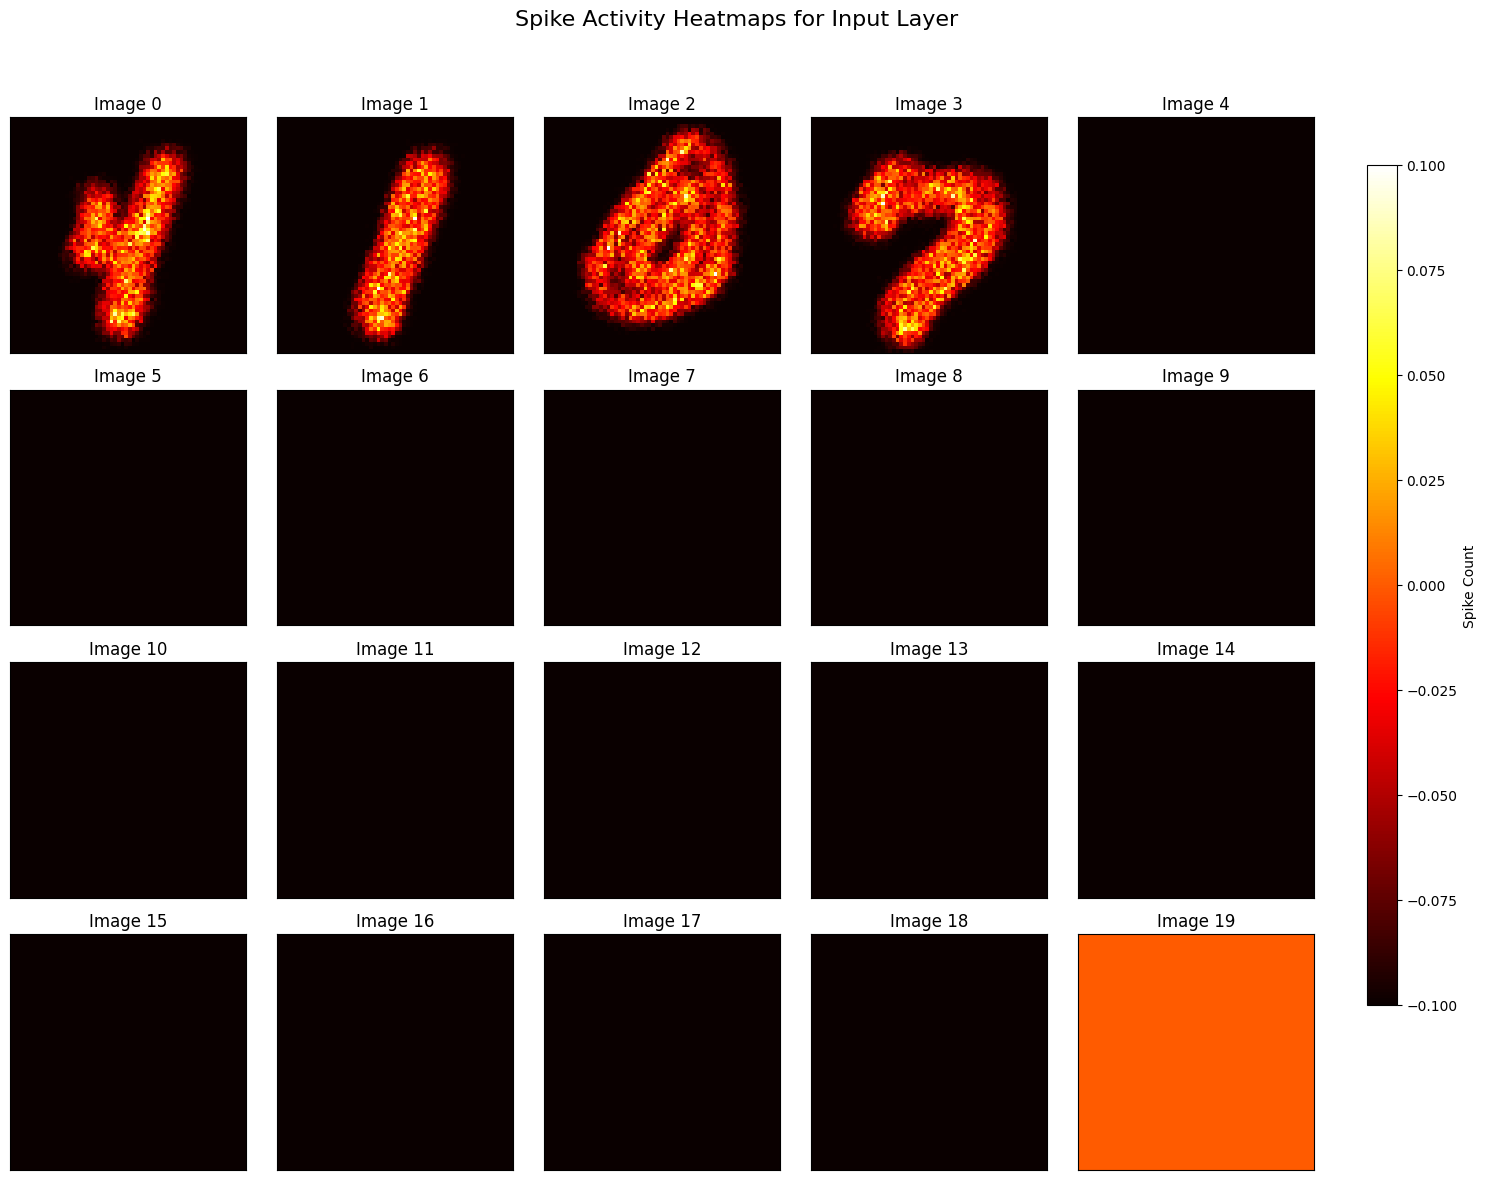

<Figure size 640x480 with 0 Axes>

In [15]:
def extract_spike_heatmap(spike_monitor, width, n_filters=1, is_input=False):
    """
    Extracts spike data and converts it into a heatmap-ready format.

    Parameters:
    - spike_monitor: Brian2 SpikeMonitor object
    - width: Grid width (e.g., 64 for your input layer)
    - n_filters: Number of filters (default = 1)
    - is_input: Boolean flag to reshape into (width, width, n_filters)

    Returns:
    - A 2D (or 3D for input neurons) numpy array of spike counts
    """
    print(f"Extracting spike data for {spike_monitor.source.name}...")
    neuron_quantity = width * width * n_filters
    spike_list = [[] for _ in range(neuron_quantity)]

    for t, i in zip(spike_monitor.t, spike_monitor.i):
        spike_list[i].append(t)

    spike_counts = np.array([len(spike_list[i]) for i in range(neuron_quantity)])
    return spike_counts.reshape(width, width, n_filters) if is_input else spike_counts.reshape(width, width)

# Function to extract spikes per image time segment
def extract_spikes_per_image(spike_monitor, image_duration, n_images, width=64):
    """
    Extract spikes for each image time segment
    
    Parameters:
    - spike_monitor: Brian2 SpikeMonitor object
    - image_duration: Duration per image in seconds
    - n_images: Number of images shown
    - width: Width of the layer (assuming square)
    
    Returns:
    - List of spike count arrays for each image time segment
    """
    spike_heatmaps = []
    
    for i in range(n_images):
        # Calculate time window for this image
        t_start = i * image_duration 
        t_end = (i + 1) * image_duration
        
        # Filter spikes in this time window
        mask = (spike_monitor.t >= t_start*second) & (spike_monitor.t < t_end*second)
        image_spikes_t = spike_monitor.t[mask]
        image_spikes_i = spike_monitor.i[mask]
        
        # Count spikes per neuron in this window
        neuron_count = width * width
        spike_counts = np.zeros(neuron_count)
        
        for neuron_idx in image_spikes_i:
            spike_counts[neuron_idx] += 1
            
        # Reshape to grid and append to results
        spike_heatmaps.append(spike_counts.reshape(width, width))
    
    return spike_heatmaps

# Extract spike heatmaps for each image
image_duration = 0.1  # 100ms
n_images = 20
width = 64  # Your input layer grid size

spike_heatmaps = extract_spikes_per_image(input_monitor, image_duration, n_images, width)

# Plot all the heatmaps
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, heatmap in enumerate(spike_heatmaps):
    if i < len(axes):  # Safety check
        ax = axes[i]
        im = ax.imshow(heatmap, cmap='hot', interpolation='nearest')
        ax.set_title(f"Image {i}")
        ax.set_xticks([])
        ax.set_yticks([])

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Spike Count')

plt.suptitle("Spike Activity Heatmaps for Input Layer", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

# You can also save the figure
plt.savefig("input_layer_spike_heatmaps.png", dpi=300, bbox_inches="tight")

In [21]:
print(ile_synapse_specs.synapse_objects[1][0].w)

<ile_1.w: array([1., 1., 1., ..., 1., 1., 1.])>


Processing Input Layer...
Processing Excitatory Layer 1...
Processing Excitatory Layer 2...
Processing Excitatory Layer 3...
Processing Excitatory Layer 4...


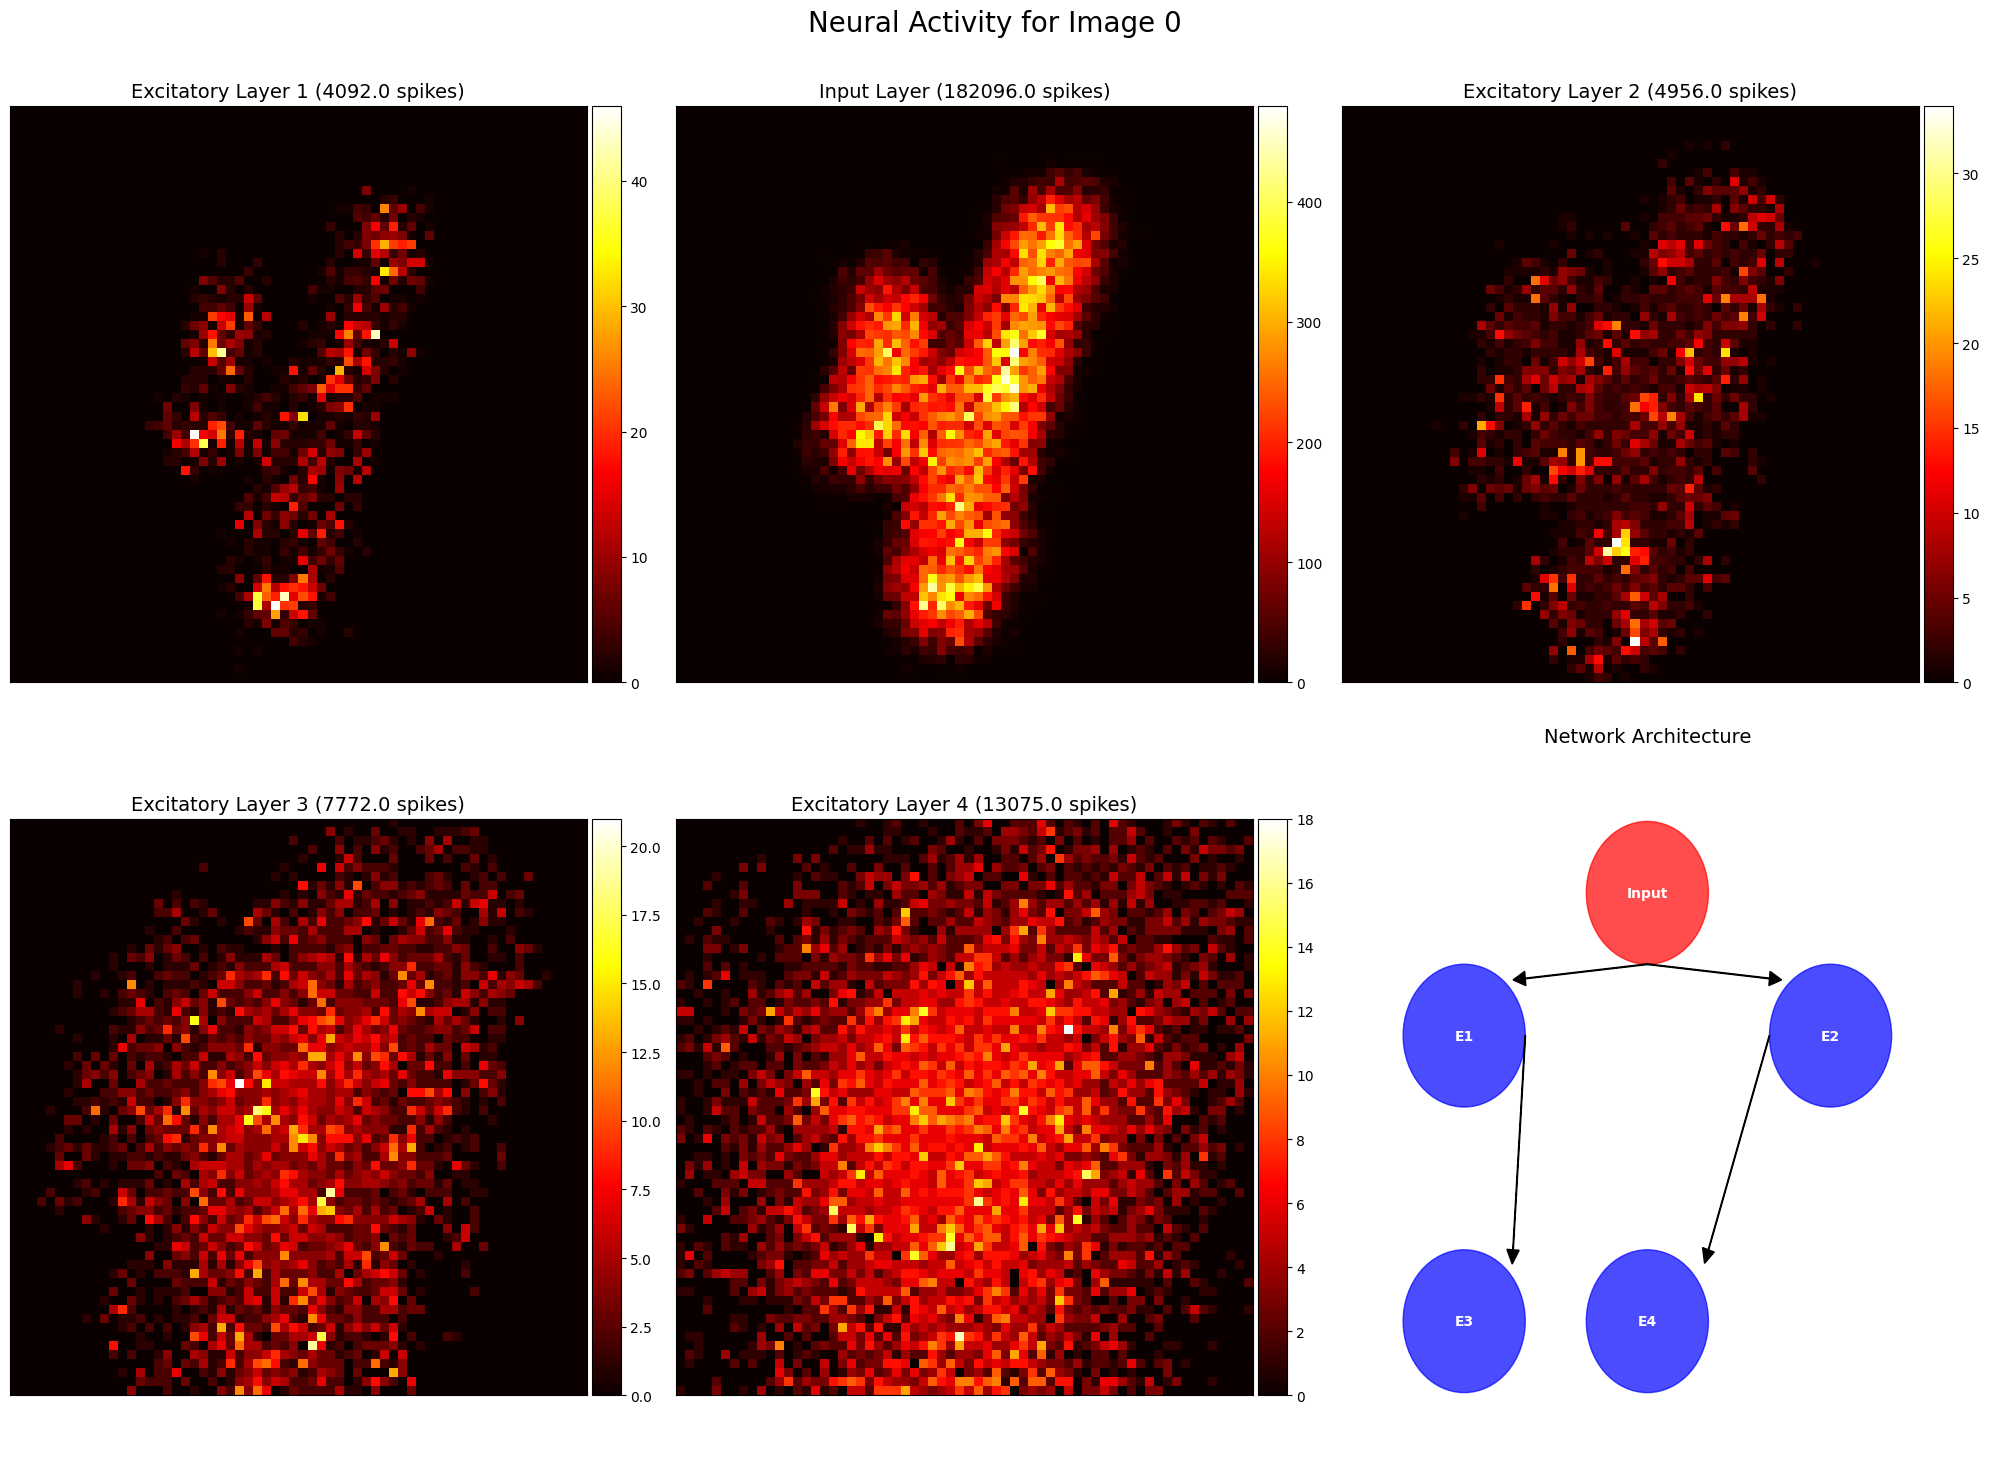

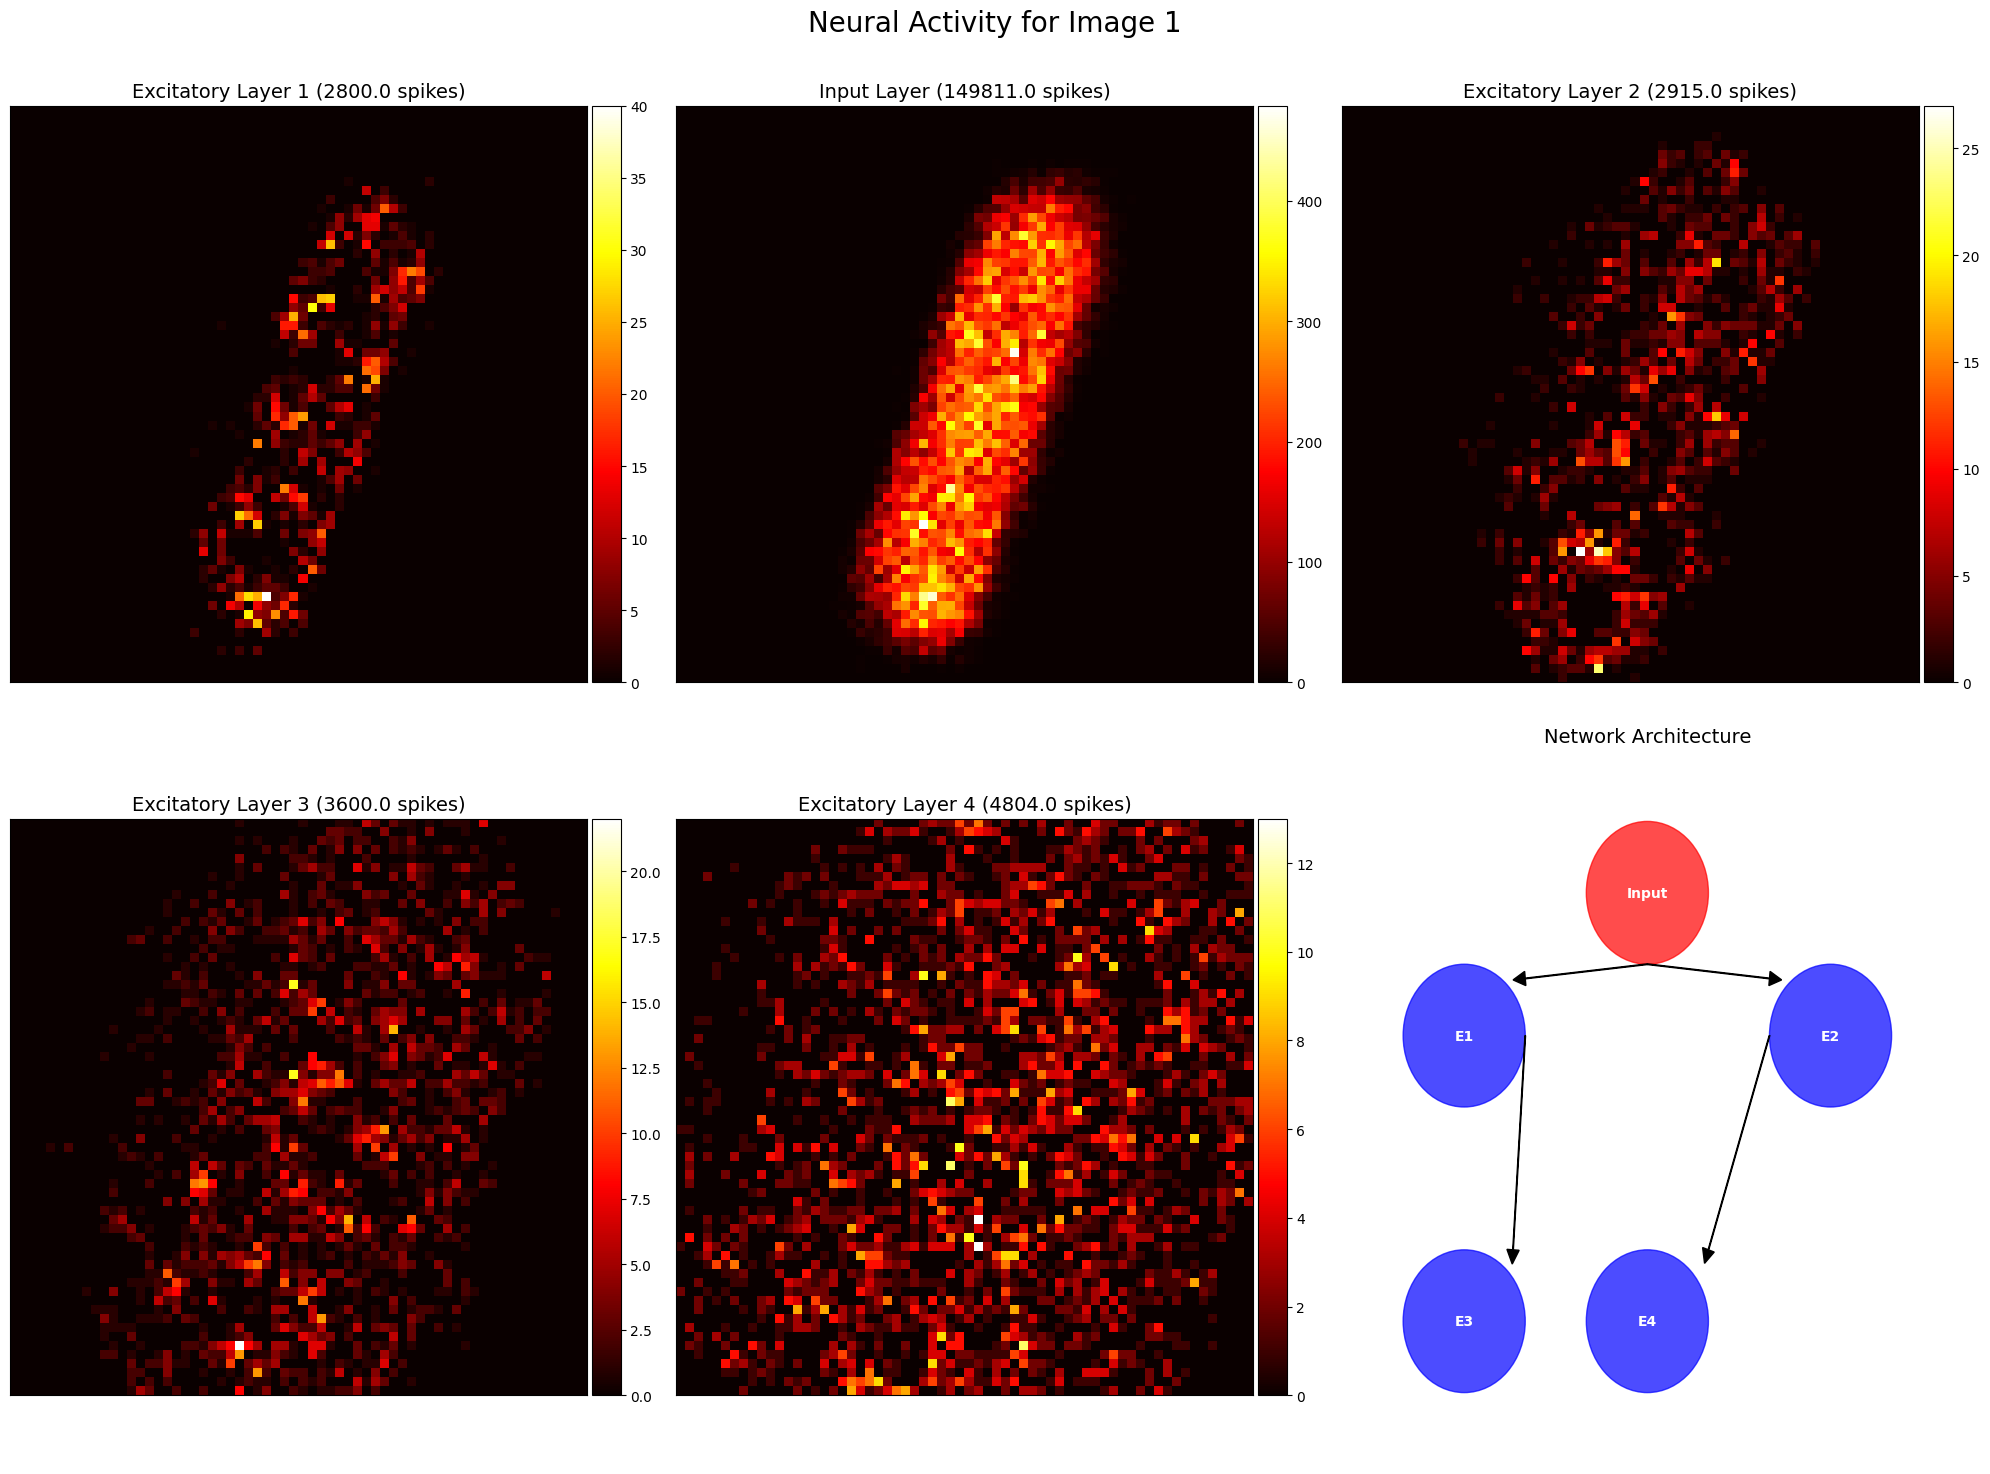

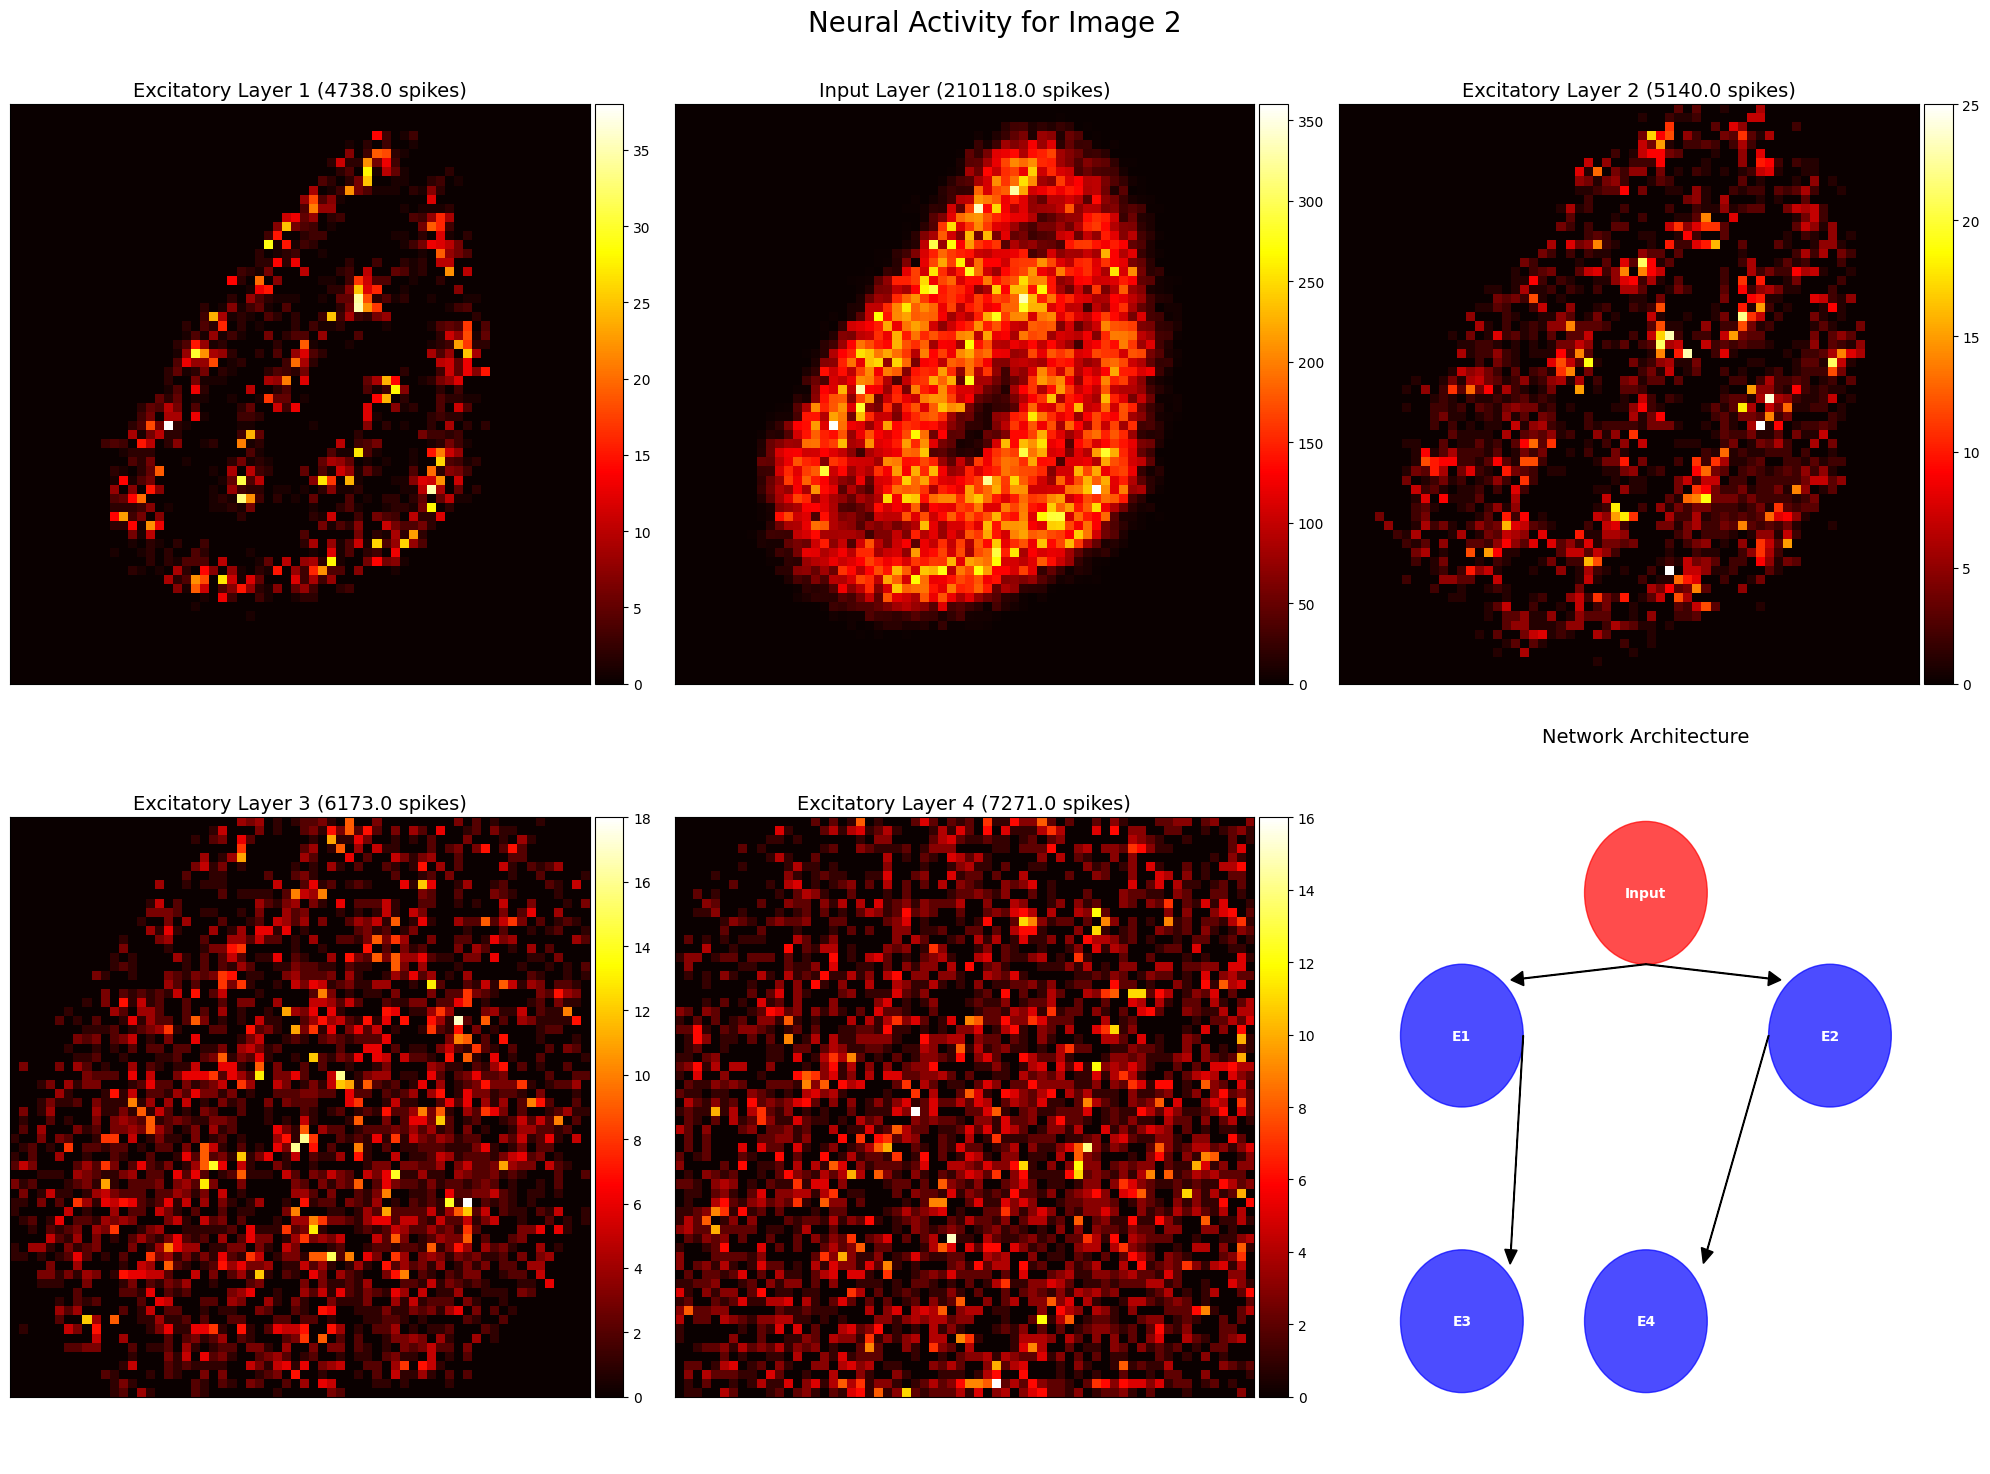

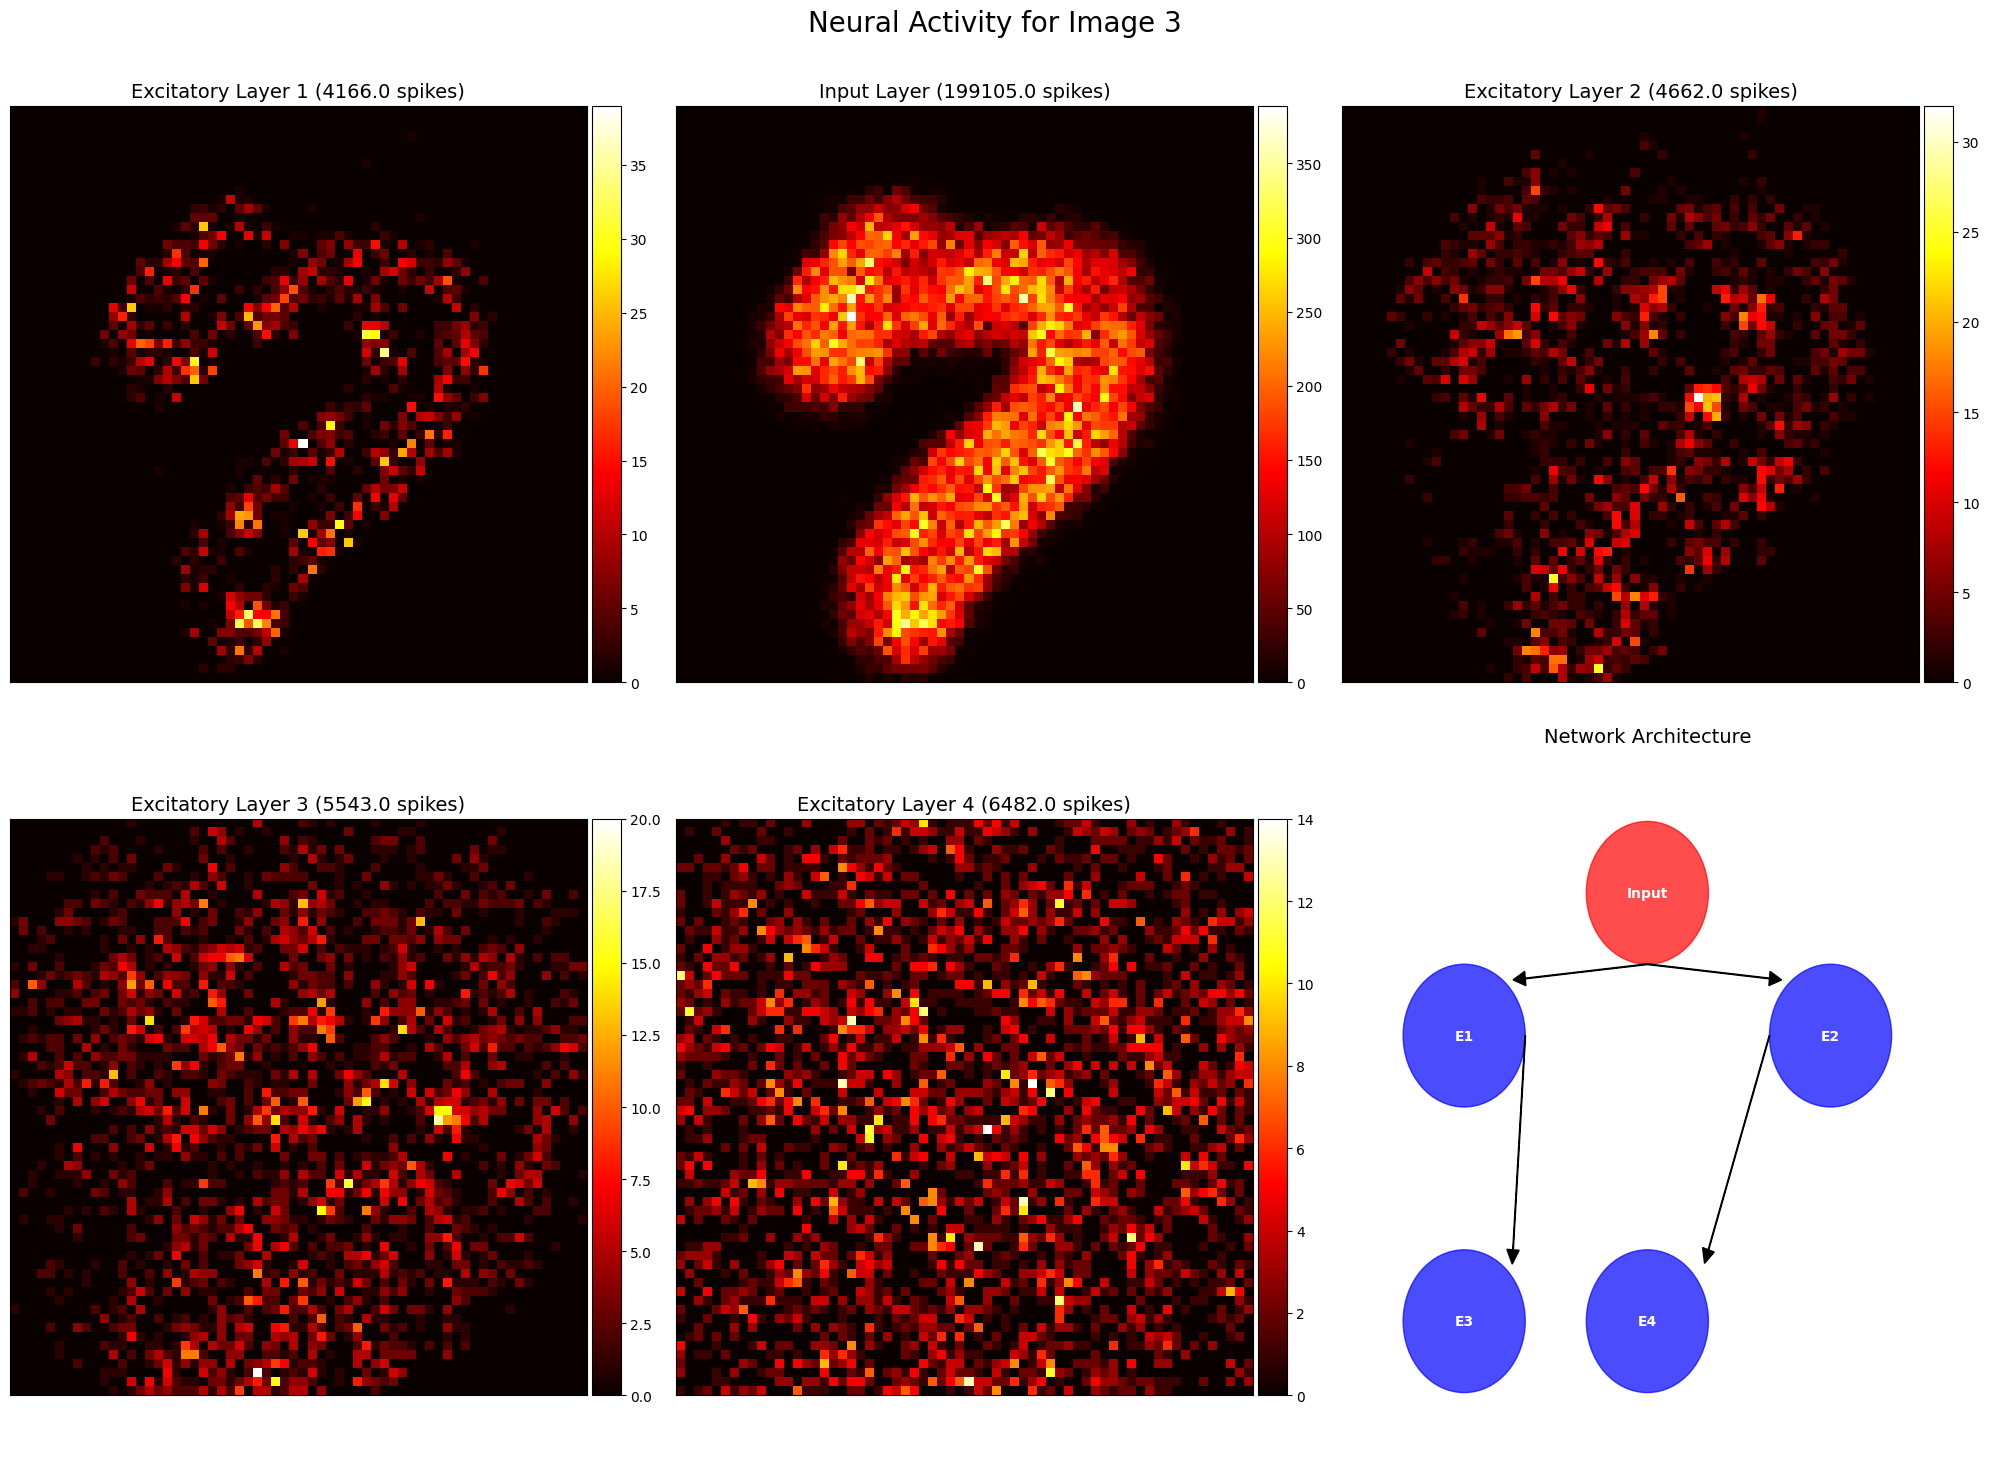

WARNING    C:\Users\reidj\AppData\Local\Temp\ipykernel_10328\346673179.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])
 [py.warnings]
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])



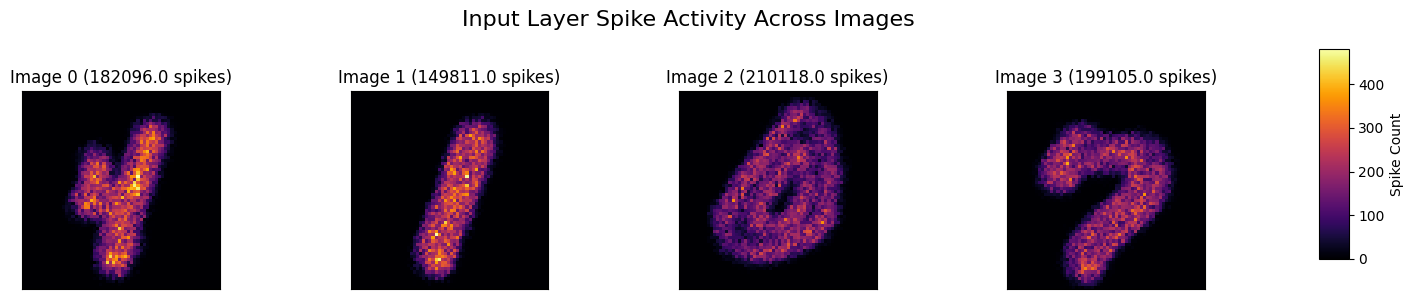

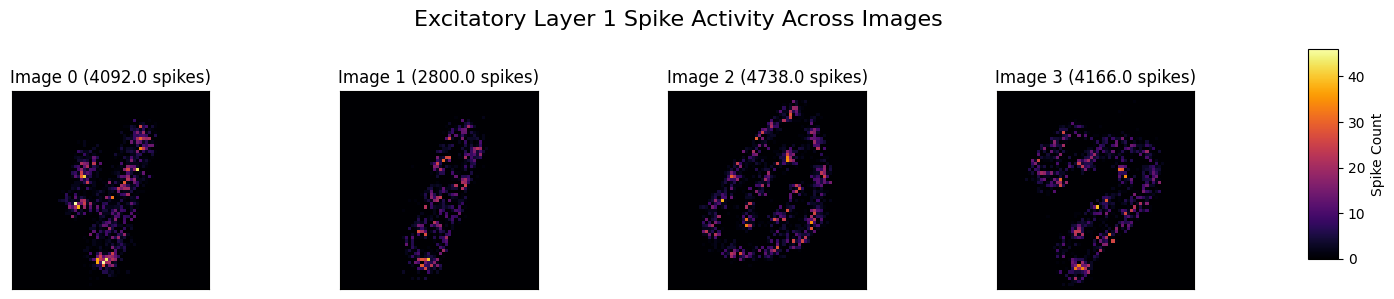

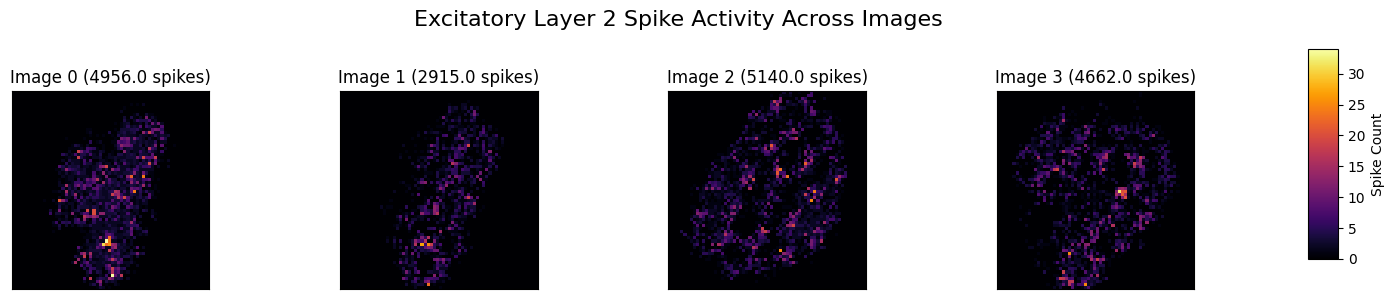

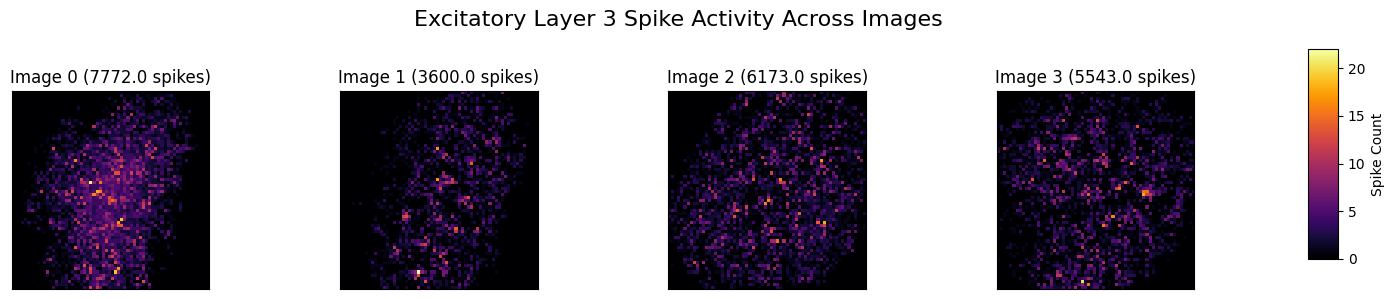

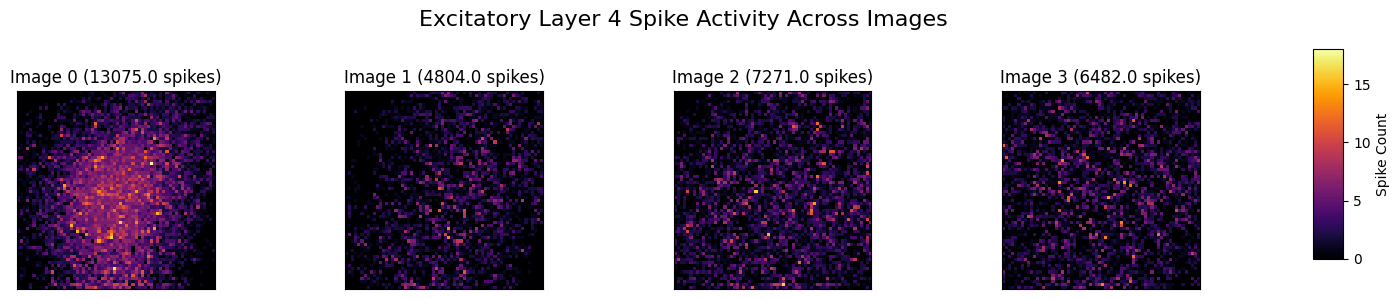

In [25]:
def visualize_all_layers_activity(monitors, image_duration=0.1, n_images=4, widths=None, cmaps=None, save_dir=None):
    """
    Visualize spike activity across all layers for each image.
    
    Parameters:
    - monitors: List of SpikeMonitor objects [input_monitor, e1_monitor, e2_monitor, e3_monitor, e4_monitor]
    - image_duration: Duration per image in seconds
    - n_images: Number of images shown
    - widths: List of widths for each layer (default: [64, 64, 64, 64, 64])
    - cmaps: List of colormaps for each layer
    - save_dir: Directory to save figures (if None, figures are only displayed)
    """
    if widths is None:
        widths = [64] * len(monitors)
        
    if cmaps is None:
        cmaps = ['hot', 'inferno', 'viridis', 'plasma', 'magma']
        
    layer_names = ["Input Layer", "Excitatory Layer 1", "Excitatory Layer 2", 
                  "Excitatory Layer 3", "Excitatory Layer 4"]
    
    # Extract spike heatmaps for each layer and image
    all_layer_heatmaps = []
    
    for i, (monitor, width) in enumerate(zip(monitors, widths)):
        print(f"Processing {layer_names[i]}...")
        layer_heatmaps = extract_spikes_per_image(monitor, image_duration, n_images, width)
        all_layer_heatmaps.append(layer_heatmaps)
    
    # Plot individual layer heatmaps for each image
    for img_idx in range(n_images):
        fig = plt.figure(figsize=(20, 15))
        
        # Create a grid: 2 rows, 3 cols (with empty space in bottom right)
        gs = plt.GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 1], height_ratios=[1, 1])
        
        # Plot each layer's activation for this image
        for layer_idx, layer_heatmaps in enumerate(all_layer_heatmaps):
            if img_idx < len(layer_heatmaps):
                # Position the subplots in a grid
                if layer_idx == 0:  # Input layer at top center
                    ax = fig.add_subplot(gs[0, 1])
                elif layer_idx == 1:  # E1 at middle left
                    ax = fig.add_subplot(gs[0, 0])
                elif layer_idx == 2:  # E2 at middle right
                    ax = fig.add_subplot(gs[0, 2])
                elif layer_idx == 3:  # E3 at bottom left
                    ax = fig.add_subplot(gs[1, 0])
                else:  # E4 at bottom center
                    ax = fig.add_subplot(gs[1, 1])
                
                # Plot the heatmap
                heatmap = layer_heatmaps[img_idx]
                if heatmap.sum() > 0:  # Only plot if there are spikes
                    im = ax.imshow(heatmap, cmap='hot', interpolation='nearest')
                    ax.set_title(f"{layer_names[layer_idx]} ({heatmap.sum()} spikes)", fontsize=14)
                else:
                    # Show empty grid if no spikes
                    im = ax.imshow(np.zeros_like(heatmap), cmap='inferno')
                    ax.set_title(f"{layer_names[layer_idx]} (No spikes)", fontsize=14)
                
                # Remove ticks for cleaner display
                ax.set_xticks([])
                ax.set_yticks([])
                
                # Add colorbar for each subplot
                divider = make_axes_locatable(ax)
                cax = divider.append_axes("right", size="5%", pad=0.05)
                plt.colorbar(im, cax=cax)
        
        # Add a "networkology diagram" to bottom right
        ax_diagram = fig.add_subplot(gs[1, 2])
        # Draw a simple network diagram
        positions = {
            'Input': (0.5, 0.8),
            'E1': (0.2, 0.6),
            'E2': (0.8, 0.6),
            'E3': (0.2, 0.2),
            'E4': (0.5, 0.2)
        }
        
        # Draw circles for each layer
        for name, (x, y) in positions.items():
            circle = plt.Circle((x, y), 0.1, 
                              color='red' if name=='Input' else 'blue', 
                              alpha=0.7)
            ax_diagram.add_patch(circle)
            ax_diagram.text(x, y, name, ha='center', va='center', color='white', fontweight='bold')
        
        # Draw connections (arrows)
        ax_diagram.arrow(0.5, 0.7, -0.2, -0.02, head_width=0.02, head_length=0.02, fc='k', ec='k')
        ax_diagram.arrow(0.5, 0.7, 0.2, -0.02, head_width=0.02, head_length=0.02, fc='k', ec='k')
        ax_diagram.arrow(0.3, 0.6, -0.02, -0.3, head_width=0.02, head_length=0.02, fc='k', ec='k')
        ax_diagram.arrow(0.7, 0.6, -0.1, -0.3, head_width=0.02, head_length=0.02, fc='k', ec='k')
        
        ax_diagram.set_xlim(0, 1)
        ax_diagram.set_ylim(0, 1)
        ax_diagram.axis('off')
        ax_diagram.set_title("Network Architecture", fontsize=14)
        
        plt.suptitle(f"Neural Activity for Image {img_idx}", fontsize=20)
        plt.tight_layout()
        
        # Save the figure if a directory is provided
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(f"{save_dir}/image_{img_idx}_all_layers.png", dpi=300, bbox_inches="tight")
        
        plt.show()
    
    # Create a summary figure showing all images for each layer
    for layer_idx, layer_heatmaps in enumerate(all_layer_heatmaps):
        if len(layer_heatmaps) > 0:
            n_cols = min(4, n_images)
            n_rows = (len(layer_heatmaps) + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
            if n_rows == 1 and n_cols == 1:
                axes = np.array([axes])
            axes = axes.flatten()
            
            # Find global min and max for consistent color scaling
            all_heatmaps = np.stack(layer_heatmaps)
            vmax = np.max(all_heatmaps) if np.max(all_heatmaps) > 0 else 1
            
            # Plot each image's activation for this layer
            for i, heatmap in enumerate(layer_heatmaps):
                if i < len(axes):
                    ax = axes[i]
                    im = ax.imshow(heatmap, cmap='inferno', interpolation='nearest', vmax=vmax)
                    ax.set_title(f"Image {i} ({heatmap.sum()} spikes)")
                    ax.set_xticks([])
                    ax.set_yticks([])
            
            # Hide unused subplots
            for i in range(len(layer_heatmaps), len(axes)):
                axes[i].axis('off')
            
            # Add colorbar
            cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
            cbar = fig.colorbar(im, cax=cbar_ax)
            cbar.set_label('Spike Count')
            
            plt.suptitle(f"{layer_names[layer_idx]} Spike Activity Across Images", fontsize=16)
            plt.tight_layout(rect=[0, 0, 0.9, 0.95])
            
            # Save the figure if a directory is provided
            if save_dir:
                plt.savefig(f"{save_dir}/{layer_names[layer_idx].replace(' ', '_')}_all_images.png", 
                           dpi=300, bbox_inches="tight")
            
            plt.show()

# Import the needed module for the colorbar positioning
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Example usage
monitors = [input_monitor, e1_monitor, e2_monitor, e3_monitor, e4_monitor]
visualize_all_layers_activity(monitors, image_duration=0.1, n_images=4, save_dir="spike_visualizations")

In [17]:
print(exc_neuron_specs.neuron_groups[3].N)

4096


In [18]:
print(len(efe_synapse_specs.synapse_objects[1][0].w))


360874
